# MCMC-ABC — Diagnostic exhaustif


This notebook contains the code to generate performance metrics on the second algorithm : MCMC ABC

## 1. Configuration globale


In [3]:
import jax
import jax.numpy as jnp
from jax import random, vmap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import time
import pandas as pd
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import os

from MCMC_ABCv2 import (
    generate_observed_data, mewe, log_prior,
    simulate, propose, make_mcmc_abc,
    find_valid_init, run_all_chains, compute_acf,
    TRUE_MU, TRUE_SIGMA, L,
    M_OBS, M_SIM, N_CHAINS, N_BURN, N_ITER, K_THIN,
    EPSILON, DELTA, S_PRIOR, T_PRIOR
)

os.makedirs("MCMC-ABC_plots", exist_ok=True)
os.makedirs("MCMC-ABC_results", exist_ok=True)

# Paramètres de l'étude
N_DATASETS        = 1    # jeux de données indépendants
N_EPSILONS        = 10   # valeurs dans le scan ε
N_DELTAS          = 7    # valeurs dans le scan δ
N_NITER_SCALING   = 7    # points pour scaling N_ITER
N_NCHAINS_SCALING = 7    # points pour scaling N_CHAINS
N_S_VALUES = 10           # valeurs dans le scan de s
N_T_VALUES = 10           # valeurs dans le scan de t
S_VALUES   = np.linspace(0.1, 3.0, N_S_VALUES)
T_VALUES   = np.linspace(0.1, 3.0, N_T_VALUES)

SECTIONS = {
    "baseline":     False,
    "scan_epsilon": False,
    "scan_delta":   False,
    "scaling_time": False,
    "scan_prior":   True,
    "recap_xlsx":   False,
}

KEY_MASTER = random.PRNGKey(42)
key_datasets, KEY_RUN = random.split(KEY_MASTER)

# Génération des N_DATASETS datasets
keys_obs = random.split(key_datasets, N_DATASETS)
DATASETS = []
for i in range(N_DATASETS):
    y = generate_observed_data(keys_obs[i], TRUE_MU, TRUE_SIGMA, M_OBS, L)
    DATASETS.append({
        "y_obs": y,
        "y_obs_sorted": jnp.sort(y)
    })

print(f"Setup : N_DATASETS={N_DATASETS}, N_CHAINS={N_CHAINS}, N_ITER={N_ITER}")
print(f"Vraies valeurs : mu={TRUE_MU}, sigma={TRUE_SIGMA}, ε={EPSILON}, δ={DELTA}")


Setup : N_DATASETS=1, N_CHAINS=1, N_ITER=40000
Vraies valeurs : mu=0.0, sigma=0.3, ε=1.5, δ=0.3


## 2. Fonctions utilitaires et métriques

### 2.1 Diagnostics statistiques


In [4]:
def r_hat(chains):
    """
    Gelman-Rubin R-hat.
    Cible : R-hat < 1.01.
    W = variance intra-chaîne (moyenne des variances par chaîne)
    B = variance inter-chaînes (variance des moyennes par chaîne, * n)
    """
    n = chains.shape[1]
    W = jnp.mean(jnp.var(chains, axis=1, ddof=1))
    B = n * jnp.var(jnp.mean(chains, axis=1), ddof=1)
    var_hat = (1 - 1/n) * W + B/n
    return float(jnp.sqrt(var_hat / W))


def compute_ess(x, max_lag=200):
    """
    ESS avec troncature dès ACF < 0.
    ESS = N / (1 + 2 * sum_k ACF(k))
    """
    x = jnp.array(x)
    acf = np.array(compute_acf(x, max_lag=max_lag))
    cutoff = int(np.argmax(acf < 0))
    if cutoff == 0:
        cutoff = max_lag
    return float(np.clip(len(x) / (1 + 2 * np.sum(acf[:cutoff])), 1, len(x)))


def compute_metrics(chains_post, acc_rates):
    """
    Calcule toutes les métriques scalaires pour un run unique.

    chains_post : (N_CHAINS, N_ITER, 2)
    acc_rates   : (N_CHAINS,)

    TROIS TYPES DE STD :
    (A) std_posterior : std sur N_CHAINS*N_ITER échantillons poolés
        = largeur de p(θ|Y_obs). Propriété du modèle.
    (B) std_mc        : std des N_CHAINS médianes
        = incertitude Monte Carlo. Propriété de l'algo.
    (C) std_ds        : calculé dans aggregate(), sur N_DATASETS valeurs
        = variabilité due au choix du dataset.
    """
    n_chains, n_iter, _ = chains_post.shape
    N_total = n_chains * n_iter

    flat_mu    = np.array(chains_post[:, :, 0]).ravel()
    flat_sigma = np.array(chains_post[:, :, 1]).ravel()

    med_mu_chains    = np.median(np.array(chains_post[:, :, 0]), axis=1)
    med_sigma_chains = np.median(np.array(chains_post[:, :, 1]), axis=1)

    q025_mu,  q50_mu,  q975_mu  = np.percentile(flat_mu,    [2.5, 50.0, 97.5])
    q025_sig, q50_sig, q975_sig = np.percentile(flat_sigma,  [2.5, 50.0, 97.5])

    ess_mu    = compute_ess(chains_post[0, :, 0])
    ess_sigma = compute_ess(chains_post[0, :, 1])

    return {
        "bias_mu"             : float(q50_mu    - TRUE_MU),
        "bias_sigma"          : float(q50_sig   - TRUE_SIGMA),
        "std_post_mu"         : float(np.std(flat_mu)),
        "std_post_sigma"      : float(np.std(flat_sigma)),
        "ic95_width_mu"       : float(q975_mu  - q025_mu),
        "ic95_width_sigma"    : float(q975_sig - q025_sig),
        "ic95_lo_mu"          : float(q025_mu),
        "ic95_hi_mu"          : float(q975_mu),
        "ic95_lo_sigma"       : float(q025_sig),
        "ic95_hi_sigma"       : float(q975_sig),
        "std_mc_mu"           : float(np.std(med_mu_chains,    ddof=1)),
        "std_mc_sigma"        : float(np.std(med_sigma_chains, ddof=1)),
        "median_mu"           : float(q50_mu),
        "median_sigma"        : float(q50_sig),
        "mean_mu"             : float(np.mean(flat_mu)),
        "mean_sigma"          : float(np.mean(flat_sigma)),
        "rhat_mu"             : r_hat(jnp.array(chains_post[:, :, 0])),
        "rhat_sigma"          : r_hat(jnp.array(chains_post[:, :, 1])),
        "ess_mu"              : ess_mu,
        "ess_sigma"           : ess_sigma,
        "ess_ratio_mu"        : ess_mu    / N_total,
        "ess_ratio_sigma"     : ess_sigma / N_total,
        "acc_mean"            : float(jnp.mean(acc_rates)),
        "acc_std"             : float(jnp.std(acc_rates)),
        "n_samples"           : N_total,
    }


def aggregate(list_metrics):
    """
    Agrège une liste de dicts (un par dataset) en mean + std_ds pour chaque clé.
    std_ds = std inter-datasets (type C) — NaN si N_DATASETS=1.
    """
    if not list_metrics:
        return {}
    keys = [k for k in list_metrics[0] if isinstance(list_metrics[0][k], float)]
    out = {"n_success": len(list_metrics)}
    for k in keys:
        vals = np.array([m[k] for m in list_metrics])
        out[f"{k}_mean"]   = float(np.mean(vals))
        out[f"{k}_std_ds"] = float(np.std(vals, ddof=1)) if len(vals) > 1 else float("nan")
    return out


print("Fonctions de diagnostic chargées.")


Fonctions de diagnostic chargées.


### 2.2 Export XLSX


In [5]:
def _style_header(ws, row, ncols, fill_hex="1a3a5c"):
    fill = PatternFill("solid", fgColor=fill_hex)
    font = Font(bold=True, color="FFFFFF", name="Arial", size=10)
    for c in range(1, ncols + 1):
        cell = ws.cell(row=row, column=c)
        cell.fill = fill
        cell.font = font
        cell.alignment = Alignment(horizontal="center", vertical="center")


def _style_data_row(ws, row, ncols, even):
    fill = PatternFill("solid", fgColor="EBF3FB" if even else "FFFFFF")
    side = Side(style="thin", color="CCCCCC")
    border = Border(left=side, right=side, top=side, bottom=side)
    font = Font(name="Arial", size=9)
    for c in range(1, ncols + 1):
        cell = ws.cell(row=row, column=c)
        cell.fill   = fill
        cell.border = border
        cell.font   = font
        cell.alignment = Alignment(horizontal="center", vertical="center")


def df_to_sheet(wb, df, sheet_name, title=None, notes=None, fill_hex="1a3a5c"):
    ws = wb.create_sheet(title=sheet_name)
    start_row = 1

    if title:
        ws.cell(row=1, column=1, value=title)
        ws.cell(row=1, column=1).font = Font(bold=True, size=12, name="Arial")
        ws.merge_cells(start_row=1, start_column=1,
                       end_row=1, end_column=len(df.columns))
        start_row = 2

    if notes:
        ws.cell(row=start_row, column=1, value=notes)
        ws.cell(row=start_row, column=1).font = Font(italic=True, size=9, name="Arial",
                                                     color="555555")
        ws.merge_cells(start_row=start_row, start_column=1,
                       end_row=start_row, end_column=len(df.columns))
        start_row += 1

    for j, col in enumerate(df.columns, 1):
        ws.cell(row=start_row, column=j, value=col)
    _style_header(ws, start_row, len(df.columns), fill_hex)

    for i, row_data in enumerate(df.itertuples(index=False), 1):
        for j, val in enumerate(row_data, 1):
            v = None if (isinstance(val, float) and np.isnan(val)) else val
            ws.cell(row=start_row + i, column=j, value=v)
        _style_data_row(ws, start_row + i, len(df.columns), i % 2 == 0)

    for j, col in enumerate(df.columns, 1):
        max_len = max(len(str(col)),
                      max((len(str(v)) for v in df[col]), default=0))
        ws.column_dimensions[get_column_letter(j)].width = min(max_len + 3, 35)

    ws.freeze_panes = ws.cell(row=start_row + 1, column=1)
    return ws


def save_workbook(wb, path):
    if "Sheet" in wb.sheetnames:
        del wb["Sheet"]
    wb.save(path)


print("Fonctions export XLSX chargées.")


Fonctions export XLSX chargées.


## 3. Run Baseline — métriques agrégées sur N_DATASETS


In [6]:
if SECTIONS["baseline"]:
    key_b = KEY_RUN
    all_base = []
    times_base = []

    for ds in tqdm(DATASETS, desc="Baseline datasets"):
        key_b, k_init, k_run = random.split(key_b, 3)
        try:
            theta0_b, _ = find_valid_init(k_init, ds["y_obs_sorted"], EPSILON)
            fn_b = make_mcmc_abc(ds["y_obs_sorted"], EPSILON, DELTA)
            t0 = time.perf_counter()
            chains_b, acc_b = run_all_chains(
                fn_b, k_run, theta0_b, EPSILON, DELTA
            )
            times_base.append(time.perf_counter() - t0)
            all_base.append(compute_metrics(chains_b, acc_b))
        except RuntimeError:
            pass

    agg_base = aggregate(all_base)
    agg_base["wall_time_mean"] = float(np.mean(times_base))
    agg_base["wall_time_std"]  = float(np.std(times_base, ddof=1))

    # Export XLSX baseline
    METRICS_META = [
        ("bias_mu",          "Biais μ",
         "médiane_post − 0.0",
         "0 = pas de biais ABC. Diminue avec ε↓"),
        ("bias_sigma",       "Biais σ",
         "médiane_post − 0.3",
         "0 = pas de biais ABC. Diminue avec ε↓"),
        ("std_post_mu",      "Std posterior μ (A)",
         "std(160k échantillons poolés)",
         "Largeur de p(μ|Y). Propriété du modèle."),
        ("std_post_sigma",   "Std posterior σ (A)",
         "std(160k échantillons poolés)",
         "Largeur de p(σ|Y). Propriété du modèle."),
        ("std_mc_mu",        "Std MC μ (B)",
         "std des 8 médianes inter-chaînes",
         "Stabilité estimateur. Diminue avec N_ITER↑"),
        ("std_mc_sigma",     "Std MC σ (B)",
         "std des 8 médianes inter-chaînes",
         "Stabilité estimateur. Diminue avec N_ITER↑"),
        ("ic95_width_mu",    "Largeur IC95 μ",
         "q97.5 − q2.5 poolés",
         "Diminue avec ε↓ et M_OBS↑"),
        ("ic95_width_sigma", "Largeur IC95 σ",
         "q97.5 − q2.5 poolés",
         "Diminue avec ε↓ et M_OBS↑"),
        ("rhat_mu",          "R-hat μ",
         "Gelman-Rubin (cible < 1.01)",
         "Convergence inter-chaînes"),
        ("rhat_sigma",       "R-hat σ",
         "Gelman-Rubin (cible < 1.01)",
         "Convergence inter-chaînes"),
        ("ess_ratio_mu",     "ESS ratio μ",
         "ESS / (N_CHAINS × N_ITER)",
         "Efficacité mixing. 1.0=parfait"),
        ("ess_ratio_sigma",  "ESS ratio σ",
         "ESS / (N_CHAINS × N_ITER)",
         "Efficacité mixing. 1.0=parfait"),
        ("acc_mean",         "Acceptance rate",
         "moy. sur 8 chaînes",
         "Cible 20–40%"),
    ]

    rows = []
    for key, label, formule, interp in METRICS_META:
        mean_val = agg_base.get(f"{key}_mean", np.nan)
        std_val  = agg_base.get(f"{key}_std_ds", np.nan)
        rows.append({
            "Métrique"                 : label,
            "Formule / calcul"         : formule,
            "Valeur (moy. datasets)"   : round(mean_val, 5) if not np.isnan(mean_val) else None,
            "Std inter-datasets (C)"   : round(std_val,  5) if not np.isnan(std_val)  else "N/A",
            "Interprétation"           : interp,
        })

    df_base = pd.DataFrame(rows)
    wb_base = openpyxl.Workbook()
    df_to_sheet(wb_base, df_base, "Métriques baseline",
                title=f"Baseline — ε={EPSILON}  N_DATASETS={N_DATASETS}  N_ITER={N_ITER}",
                notes="(A)=std posterior  (B)=std Monte Carlo  (C)=std inter-datasets")
    save_workbook(wb_base, "MCMC-ABC_results/baseline_metrics.xlsx")
    print("=> MCMC-ABC_results/baseline_metrics.xlsx")


## 4. Scan ε — parallélisé via double vmap

**Notes on the vmapping:**
- Level 1 (Python) : for loop on the N_DATASETS datasets
- Level 2 (JAX vmap) : vmap of `mcmc_abc_single` on the N_EPSILONS values of ε
- Level 3 (JAX vmap) : vmap of `mcmc_abc_single` on the N_CHAINS keys

In [7]:
if SECTIONS["scan_epsilon"]:
    EPSILONS    = jnp.array(np.linspace(0.05, 3.0, N_EPSILONS))
    DELTA_FIXED = DELTA  # pas de proposition fixé pendant le scan ε

    # theta0 commun (premier dataset, epsilon médian)
    eps_mid = float(EPSILONS[N_EPSILONS // 2])
    theta0_eps, key_eps_base = find_valid_init(
        random.PRNGKey(300), DATASETS[0]["y_obs_sorted"], eps_mid
    )

    all_eps_per_ds = []   # liste (N_DATASETS,) de listes de dicts (N_EPSILONS,)

    for ds_idx, ds in enumerate(tqdm(DATASETS, desc="Scan ε — datasets")):
        key_eps_base, k_init, k_all = random.split(key_eps_base, 3)

        try:
            theta0_ds, _ = find_valid_init(
                k_init, ds["y_obs_sorted"], eps_mid, n_tries=5000
            )
        except RuntimeError:
            theta0_ds = theta0_eps  # fallback

        # keys_batch[i, j] = clé pour (epsilon_i, chain_j)
        keys_batch = random.split(k_all, N_EPSILONS * N_CHAINS).reshape(
            N_EPSILONS, N_CHAINS, 2
        )

        # Construction de mcmc_abc_single pour ce dataset
        mcmc_abc_single = make_mcmc_abc(ds["y_obs_sorted"], EPSILON, DELTA)

        # vmap interne : sur les N_CHAINS clés (4 args, n_total = default Python)
        run_chains = jax.vmap(mcmc_abc_single, in_axes=(0, None, None, None))

        # vmap externe : sur les N_EPSILONS valeurs de ε
        # in_axes=(0, None, 0, None) / keys_batch[i] et EPSILONS[i]
        run_scan_eps = jax.jit(
            jax.vmap(run_chains, in_axes=(0, None, 0, None))
        )

        t0 = time.perf_counter()
        all_samples, all_acc = run_scan_eps(
            keys_batch, theta0_ds, EPSILONS, jnp.array(DELTA_FIXED)
        )
        # all_samples.shape = (N_EPSILONS, N_CHAINS, N_BURN+N_ITER, 2)
        # all_acc.shape     = (N_EPSILONS, N_CHAINS)
        chains_post_eps = all_samples[:, :, N_BURN:, :]  # post burn-in
        elapsed = time.perf_counter() - t0
        print(f"  Dataset {ds_idx} — {N_EPSILONS} valeurs ε en {elapsed:.1f}s")

        # Post-traitement Python : compute_metrics pour chaque ε
        ds_results = []
        for j in range(N_EPSILONS):
            m = compute_metrics(np.array(chains_post_eps[j]), np.array(all_acc[j]))
            m["epsilon"] = float(EPSILONS[j])
            ds_results.append(m)
        all_eps_per_ds.append(ds_results)

    # Agrégation : pour chaque epsilon, moyenner sur les N_DATASETS
    results_eps_agg = []
    for j in range(N_EPSILONS):
        metrics_for_eps_j = [all_eps_per_ds[ds_idx][j] for ds_idx in range(len(all_eps_per_ds))]
        agg_j = aggregate(metrics_for_eps_j)
        agg_j["epsilon"] = float(EPSILONS[j])
        results_eps_agg.append(agg_j)

    df_eps = pd.DataFrame(results_eps_agg)

    # Export XLSX
    cols_eps = ["epsilon",
                "bias_mu_mean",       "bias_mu_std_ds",
                "bias_sigma_mean",    "bias_sigma_std_ds",
                "acc_mean_mean",      "acc_mean_std_ds",
                "ess_ratio_mu_mean",  "ess_ratio_mu_std_ds",
                "ic95_width_mu_mean", "ic95_width_mu_std_ds",
                "rhat_mu_mean",       "rhat_mu_std_ds",
                "std_mc_mu_mean",     "std_mc_mu_std_ds"]
    cols_eps = [c for c in cols_eps if c in df_eps.columns]
    df_eps_out = df_eps[cols_eps].round(5)

    wb_eps = openpyxl.Workbook()
    df_to_sheet(wb_eps, df_eps_out, "Scan epsilon",
                title=f"Scan ε — N_DATASETS={N_DATASETS}  δ={DELTA_FIXED} fixé",
                notes="_mean = moyenne sur datasets  _std_ds = std inter-datasets (type C)")
    save_workbook(wb_eps, "MCMC-ABC_results/scan_epsilon.xlsx")
    print("→ MCMC-ABC_results/scan_epsilon.xlsx")


In [8]:
if SECTIONS["scan_epsilon"] and 'df_eps' in dir():
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    fig.suptitle(
        f"Sensibilité à ε — MCMC-ABC  [{N_DATASETS} datasets, {N_EPSILONS} valeurs]",
        fontsize=13, fontweight="bold"
    )
    eps_vals = df_eps["epsilon"].values

    PLOTS_EPS = [
        ("bias_mu",          "Biais μ",
         "médiane post − 0.0\nbande = ±std inter-datasets",  0.0, "steelblue"),
        ("bias_sigma",       "Biais σ",
         "médiane post − 0.3",                               0.0, "steelblue"),
        ("acc_mean",         "Acceptance rate",
         "cible 20–40%",                                     None, "darkorange"),
        ("ess_ratio_mu",     "ESS ratio μ",
         "ESS/(N_CHAINS×N_ITER)",                            None, "steelblue"),
        ("ess_ratio_sigma",  "ESS ratio σ",
         "ESS/(N_CHAINS×N_ITER)",                            None, "steelblue"),
        ("ic95_width_mu",    "Largeur IC95 μ",
         "q97.5−q2.5 poolés",                                None, "steelblue"),
        ("rhat_mu",          "R-hat μ",
         "cible < 1.01",                                     1.01, "crimson"),
        ("rhat_sigma",       "R-hat σ",
         "cible < 1.01",                                     1.01, "crimson"),
        ("std_mc_mu",        "Std MC μ (B)",
         "stabilité estimateur",                             None, "purple"),
    ]

    for ax, (col, title, desc, hline, color) in zip(axes.ravel(), PLOTS_EPS):
        col_m = f"{col}_mean"
        col_s = f"{col}_std_ds"
        if col_m not in df_eps.columns:
            ax.set_visible(False)
            continue
        y = df_eps[col_m].values
        ax.plot(eps_vals, y, lw=2, color=color)
        if col_s in df_eps.columns:
            sd = df_eps[col_s].fillna(0).values
            ax.fill_between(eps_vals, y - sd, y + sd,
                            alpha=0.2, color=color, label="±std inter-ds")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("ε", fontsize=9)
        ax.text(0.98, 0.95, desc, transform=ax.transAxes, fontsize=7,
                ha="right", va="top",
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))
        if hline is not None:
            ax.axhline(hline, color="k", lw=0.8, ls="--")
        if "bias" in col:
            ax.axhline(0, color="k", lw=0.8, ls="--")
        if "acc" in col:
            ax.axhspan(0.20, 0.40, alpha=0.12, color="green")
        ax.legend(fontsize=6)

    plt.tight_layout()
    plt.savefig("MCMC-ABC_plots/scan_epsilon.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5. Scan δ — parallélisé via double vmap

Same structure as the scan on ε, vmapping on the N_DELTAS values of δ this time.

In [9]:
if SECTIONS["scan_delta"]:
    DELTAS    = jnp.array(np.linspace(0.01, 0.8, N_DELTAS))
    EPS_FIXED = EPSILON

    theta0_delta, key_delta_base = find_valid_init(
        random.PRNGKey(400), DATASETS[0]["y_obs_sorted"], EPS_FIXED
    )

    all_delta_per_ds = []

    for ds_idx, ds in enumerate(tqdm(DATASETS, desc="Scan δ — datasets")):
        key_delta_base, k_init, k_all = random.split(key_delta_base, 3)

        try:
            theta0_ds, _ = find_valid_init(
                k_init, ds["y_obs_sorted"], EPS_FIXED, n_tries=5000
            )
        except RuntimeError:
            theta0_ds = theta0_delta

        # keys_batch[i, j] = clé pour (delta_i, chain_j)
        keys_batch = random.split(k_all, N_DELTAS * N_CHAINS).reshape(
            N_DELTAS, N_CHAINS, 2
        )

        # Construction de mcmc_abc_single pour ce dataset
        mcmc_abc_single = make_mcmc_abc(ds["y_obs_sorted"], EPSILON, DELTA)

        # vmap interne : sur les N_CHAINS clés (4 args, n_total = default Python)
        run_chains = jax.vmap(mcmc_abc_single, in_axes=(0, None, None, None))

        # vmap externe : sur les N_DELTAS valeurs de δ
        # in_axes=(0, None, None, 0) — keys_batch[i] et DELTAS[i]
        run_scan_delta = jax.jit(
            jax.vmap(run_chains, in_axes=(0, None, None, 0))
        )

        t0 = time.perf_counter()
        all_samples, all_acc = run_scan_delta(
            keys_batch, theta0_ds,
            jnp.array(EPS_FIXED), DELTAS
        )
        # all_samples.shape = (N_DELTAS, N_CHAINS, N_BURN+N_ITER, 2)
        # all_acc.shape     = (N_DELTAS, N_CHAINS)
        chains_post_delta = all_samples[:, :, N_BURN:, :]  # post burn-in
        elapsed = time.perf_counter() - t0
        print(f"  Dataset {ds_idx} — {N_DELTAS} valeurs δ en {elapsed:.1f}s")

        ds_results = []
        for j in range(N_DELTAS):
            m = compute_metrics(np.array(chains_post_delta[j]), np.array(all_acc[j]))
            m["delta"] = float(DELTAS[j])
            ds_results.append(m)
        all_delta_per_ds.append(ds_results)

    results_delta_agg = []
    for j in range(N_DELTAS):
        metrics_j = [all_delta_per_ds[ds_idx][j] for ds_idx in range(len(all_delta_per_ds))]
        agg_j = aggregate(metrics_j)
        agg_j["delta"] = float(DELTAS[j])
        results_delta_agg.append(agg_j)

    df_delta = pd.DataFrame(results_delta_agg)

    # Export XLSX
    cols_d = ["delta",
              "acc_mean_mean",     "acc_mean_std_ds",
              "ess_ratio_mu_mean", "ess_ratio_mu_std_ds",
              "bias_mu_mean",      "bias_mu_std_ds",
              "bias_sigma_mean",   "bias_sigma_std_ds",
              "rhat_mu_mean",      "rhat_mu_std_ds",
              "std_mc_mu_mean",    "std_mc_mu_std_ds"]
    cols_d = [c for c in cols_d if c in df_delta.columns]
    df_delta_out = df_delta[cols_d].round(5)

    wb_d = openpyxl.Workbook()
    df_to_sheet(wb_d, df_delta_out, "Scan delta",
                title=f"Scan δ — N_DATASETS={N_DATASETS}  ε={EPS_FIXED} fixé",
                notes="_mean=moy. datasets  _std_ds=std inter-datasets")
    save_workbook(wb_d, "MCMC-ABC_results/scan_delta.xlsx")
    print("→ MCMC-ABC_results/scan_delta.xlsx")


In [10]:
if SECTIONS["scan_delta"] and 'df_delta' in dir():
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(
        f"Sensibilité au pas de proposition δ  [ε={EPS_FIXED}, {N_DATASETS} datasets]",
        fontsize=12, fontweight="bold"
    )
    d_vals = df_delta["delta"].values

    PLOTS_D = [
        (axes[0,0], "acc_mean",        "Acceptance rate",   "darkorange"),
        (axes[0,1], "ess_ratio_mu",    "ESS ratio μ",       "steelblue"),
        (axes[0,2], "ess_ratio_sigma", "ESS ratio σ",       "steelblue"),
        (axes[1,0], "bias_mu",         "Biais μ",           "steelblue"),
        (axes[1,1], "bias_sigma",      "Biais σ",           "steelblue"),
        (axes[1,2], "std_mc_mu",       "Std MC μ (B)",      "purple"),
    ]

    for ax, col, title, color in PLOTS_D:
        col_m = f"{col}_mean"
        col_s = f"{col}_std_ds"
        if col_m not in df_delta.columns:
            continue
        y = df_delta[col_m].values
        ax.plot(d_vals, y, lw=2, color=color)
        if col_s in df_delta.columns:
            sd = df_delta[col_s].fillna(0).values
            ax.fill_between(d_vals, y - sd, y + sd,
                            alpha=0.2, color=color, label="±std inter-ds")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("δ", fontsize=9)
        ax.legend(fontsize=7)
        if "bias" in col:
            ax.axhline(0, color="k", lw=0.8, ls="--")
        if "acc" in col:
            ax.axhspan(0.20, 0.40, alpha=0.12, color="green")

    plt.tight_layout()
    plt.savefig("MCMC-ABC_plots/scan_delta.png", dpi=150, bbox_inches="tight")
    plt.show()


## 6. Scaling temporel

This section produces metrics on the computational time of the algorithm


In [11]:
if SECTIONS["scaling_time"]:
    ds_ref  = DATASETS[0]
    fn_time = make_mcmc_abc(ds_ref["y_obs_sorted"], EPSILON, DELTA)
    theta0_t, key_t = find_valid_init(
        random.PRNGKey(500), ds_ref["y_obs_sorted"], EPSILON
    )

    # vmap sur les N_CHAINS clés => 5 axes pour passer n_total comme int Python explicite
    # in_axes=(0, None, None, None, None) : seule la clé est vmappée
    mcmc_v = jax.vmap(fn_time, in_axes=(0, None, None, None, None))

    # Scaling N_ITER
    N_ITER_VALS = np.unique(np.round(np.linspace(500, 25_000, N_NITER_SCALING)).astype(int))
    rows_niter = []

    # Warmup JIT : n_total comme int Python (JAX trace sur cette valeur)
    key_t, k_w = random.split(key_t)
    result_w = mcmc_v(random.split(k_w, N_CHAINS), theta0_t,
               jnp.array(EPSILON), jnp.array(DELTA), N_BURN + 200)
    result_w[0].block_until_ready()

    for n_it in tqdm(N_ITER_VALS, desc="Scaling N_ITER"):
        key_t, k_run = random.split(key_t)
        n_total_it = N_BURN + int(n_it)   # entier Python pur
        # jax.jit recompile pour chaque nouvelle valeur de n_total (comportement voulu)
        mcmc_v_it = jax.jit(jax.vmap(fn_time, 
                                     in_axes=(0, None, None, None, None)),
                                     static_argnums=(4,)   # n_total est l'argument d'indice 4 — statique
                        )
        t0 = time.perf_counter()
        result = mcmc_v_it(random.split(k_run, N_CHAINS), theta0_t,
                      jnp.array(EPSILON), jnp.array(DELTA), n_total_it)
        result[0].block_until_ready()          # Fin du chrono lorsqu'on a un output.
        rows_niter.append({"n_iter": int(n_it), "time_s": time.perf_counter() - t0})

    df_niter = pd.DataFrame(rows_niter)

    # Scaling N_CHAINS
    key_c = random.PRNGKey(600)
    rows_nchains = []
    n_total_fixed = N_BURN + N_ITER  # entier Python pur

    for n_ch in tqdm(range(1, N_NCHAINS_SCALING + 1), desc="Scaling N_CHAINS"):
        key_c, k_run, k_w = random.split(key_c, 3)
        subkeys = random.split(k_run, n_ch)
        mcmc_v_ch = jax.jit(jax.vmap(fn_time,
                                     in_axes=(0, None, None, None, None)),
                                     static_argnums=(4,)
                        )
        # Warmup pour ce n_ch (compile pour ce nombre de chaînes)
        result_w = mcmc_v_ch(random.split(k_w, n_ch), theta0_t,
                      jnp.array(EPSILON), jnp.array(DELTA), N_BURN + 200)
        result_w[0].block_until_ready()
        t0 = time.perf_counter()
        result = mcmc_v_ch(subkeys, theta0_t,
                      jnp.array(EPSILON), jnp.array(DELTA), n_total_fixed)
        result[0].block_until_ready()
        rows_nchains.append({"n_chains": n_ch, "time_s": time.perf_counter() - t0})

    df_nchains = pd.DataFrame(rows_nchains)

    # Export XLSX
    wb_time = openpyxl.Workbook()
    df_to_sheet(wb_time, df_niter.round(4), "Scaling N_ITER",
                title="Scaling temporel — N_ITER",
                notes="Si linéaire : chaque itération coûte le même temps (fori_loop compilé)")
    df_to_sheet(wb_time, df_nchains.round(4), "Scaling N_CHAINS",
                title="Scaling temporel — N_CHAINS (vmap)",
                notes="Si sous-linéaire : vmap exploite le parallélisme")
    save_workbook(wb_time, "MCMC-ABC_results/scaling_time.xlsx")
    print("→ MCMC-ABC_results/scaling_time.xlsx")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Temps de calcul — scaling", fontsize=12, fontweight="bold")

    axes[0].plot(df_niter["n_iter"], df_niter["time_s"],
                 lw=2, color="steelblue", marker="o", ms=4)
    axes[0].set_xlabel("N_ITER")
    axes[0].set_ylabel("Temps (s)")
    axes[0].set_title("Scaling N_ITER (N_CHAINS fixé)")

    axes[1].plot(df_nchains["n_chains"], df_nchains["time_s"],
                 lw=2, color="darkorange", marker="o", ms=4)
    axes[1].set_xlabel("N_CHAINS")
    axes[1].set_ylabel("Temps (s)")
    axes[1].set_title("Scaling N_CHAINS (vmap)")

    plt.tight_layout()
    plt.savefig("MCMC-ABC_plots/scaling_time.png", dpi=150, bbox_inches="tight")
    plt.show()


## 7. Scan sur les prior s et s

In this section, we study the influence of s and t (prior parameters) on the performance metrics.

NB: After running our algorithm on multiple datasets, using multiple chains at once, we noticed that inter-datasets std (C) and MC (B) are negligeable. For faster computations, this scan will be performed on a single dataset, with a single chain.

Scan (s, t) : 10 × 10 = 100 runs
ε=1.5, δ=0.3, 1 chaîne, 1 dataset, N_BURN=8000, N_ITER=40000


Scan s: 100%|██████████| 10/10 [13:56:38<00:00, 5019.86s/it] 


     s       t   bias_mu  bias_sigma  acc_rate  ess_ratio_mu
0  0.1  0.1000 -0.235570    0.455782  0.003625      0.003722
1  0.1  0.4222 -0.114480    0.339585  0.069585      0.036270
2  0.1  0.7444 -0.076456    0.258835  0.132086      0.058145
3  0.1  1.0667 -0.051483    0.191049  0.174774      0.072273
4  0.1  1.3889 -0.035821    0.142875  0.202713      0.060730
5  0.1  1.7111 -0.028419    0.082651  0.227484      0.069649
6  0.1  2.0333 -0.023309    0.053561  0.236567      0.057973
7  0.1  2.3556 -0.017209    0.003372  0.252630      0.054597
8  0.1  2.6778 -0.013513   -0.020818  0.256610      0.062161
9  0.1  3.0000 -0.010602   -0.044031  0.261068      0.056923
→ MCMC-ABC_results/scan_prior_st.xlsx


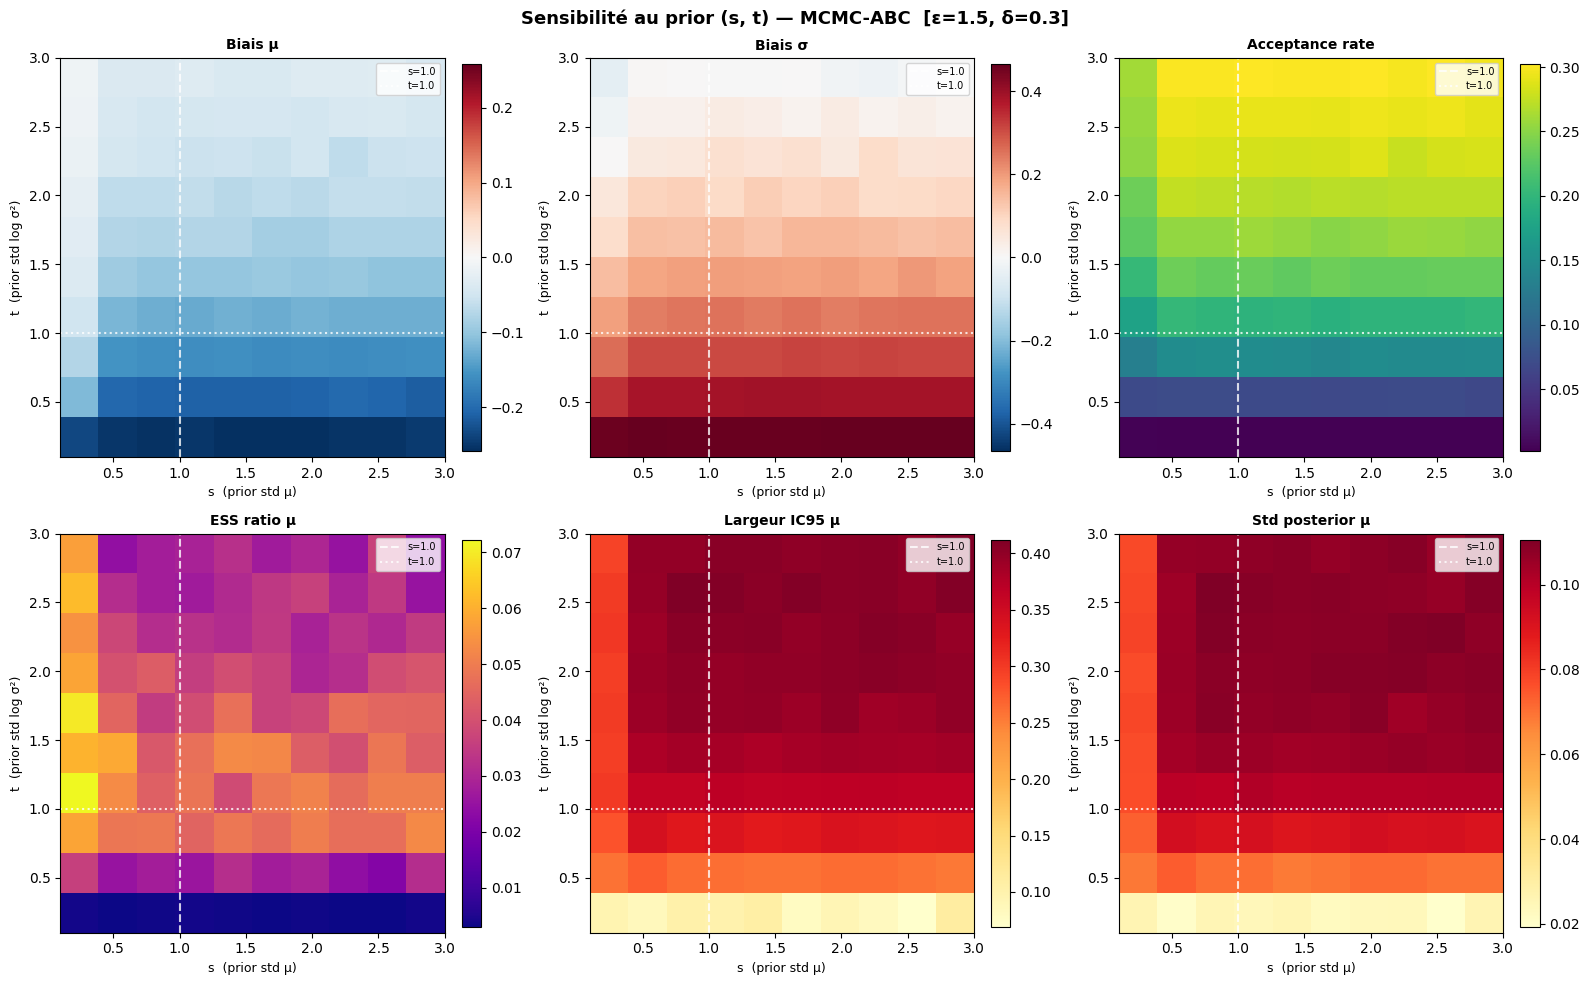

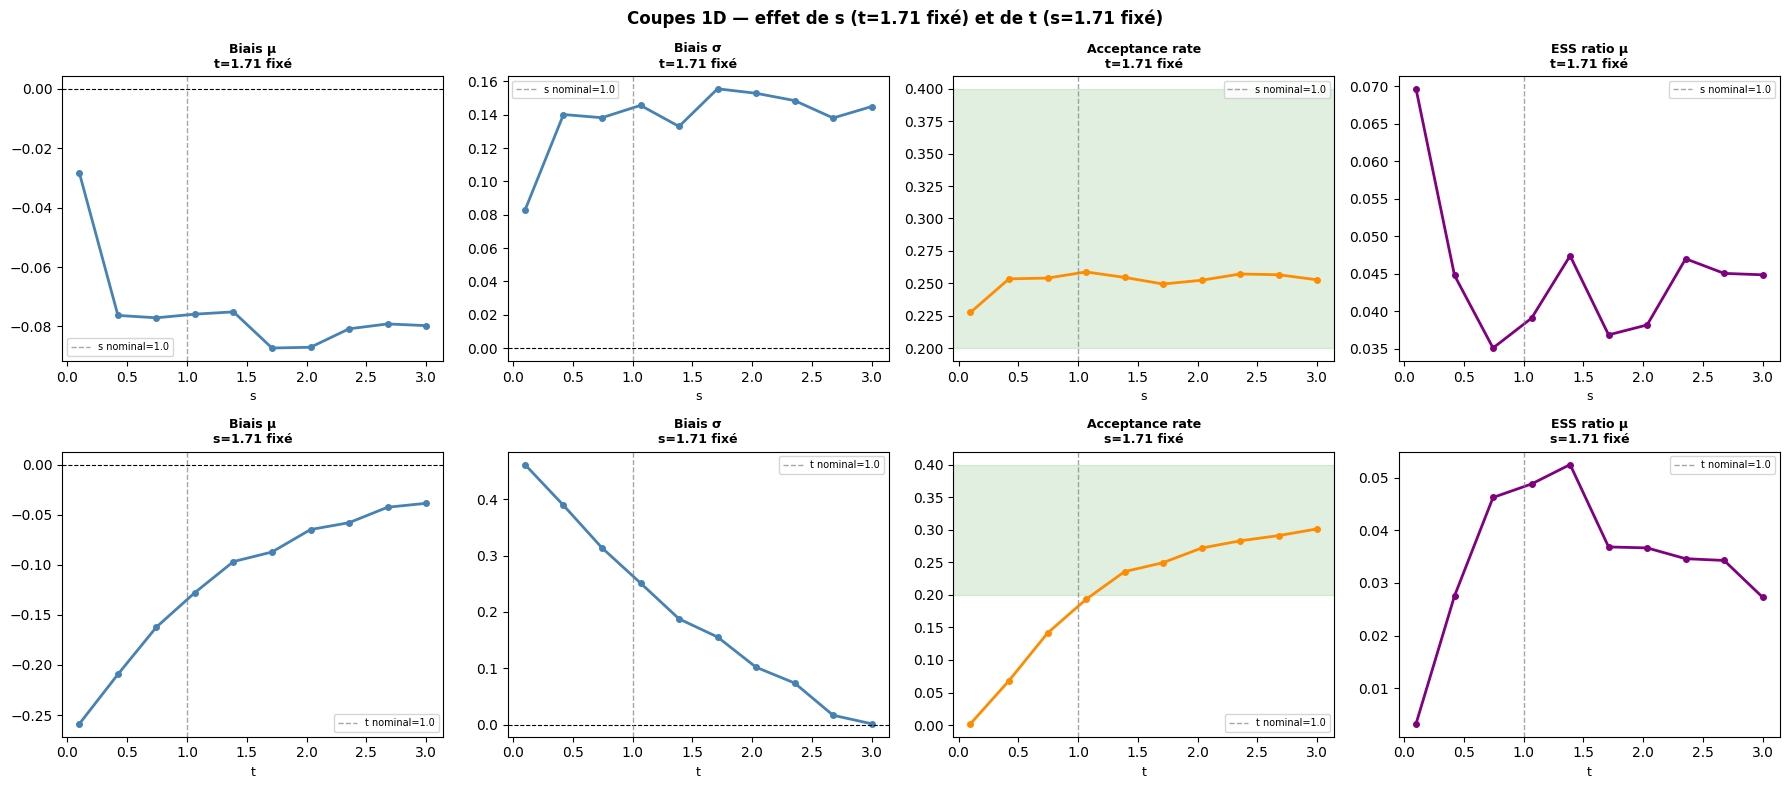

In [12]:
if SECTIONS["scan_prior"]:
    DS_REF   = DATASETS[0]
    EPS_ST   = EPSILON
    DELTA_ST = DELTA

    print(f"Scan (s, t) : {N_S_VALUES} × {N_T_VALUES} = {N_S_VALUES * N_T_VALUES} runs")
    print(f"ε={EPS_ST}, δ={DELTA_ST}, 1 chaîne, 1 dataset, N_BURN={N_BURN}, N_ITER={N_ITER}")

    rows_st = []
    key_st  = random.PRNGKey(700)

    for s_val in tqdm(S_VALUES, desc="Scan s"):
        for t_val in T_VALUES:
            key_st, k_init, k_run = random.split(key_st, 3)

            try:
                theta0_st, _ = find_valid_init(k_init, DS_REF["y_obs_sorted"], EPS_ST)
            except RuntimeError:
                rows_st.append({"s": float(s_val), "t": float(t_val),
                                **{k: np.nan for k in ["bias_mu", "bias_sigma",
                                "std_post_mu", "std_post_sigma",
                                "ic95_width_mu", "ic95_width_sigma",
                                "acc_rate", "ess_ratio_mu", "ess_ratio_sigma"]}})
                continue

            fn_st    = make_mcmc_abc(DS_REF["y_obs_sorted"], EPS_ST, DELTA_ST,
                                    s=s_val, t=t_val)
            fn_st_jit = jax.jit(fn_st)
            samples, acc = fn_st_jit(k_run, theta0_st, EPS_ST, DELTA_ST)

            chain_post = np.array(samples[N_BURN:])   # (N_ITER, 2)
            flat_mu    = chain_post[:, 0]
            flat_sigma = chain_post[:, 1]

            q025_mu,  q50_mu,  q975_mu  = np.percentile(flat_mu,    [2.5, 50.0, 97.5])
            q025_sig, q50_sig, q975_sig = np.percentile(flat_sigma,  [2.5, 50.0, 97.5])
            ess_mu    = compute_ess(chain_post[:, 0])
            ess_sigma = compute_ess(chain_post[:, 1])

            rows_st.append({
                "s"               : round(float(s_val), 4),
                "t"               : round(float(t_val), 4),
                "bias_mu"         : float(q50_mu   - TRUE_MU),
                "bias_sigma"      : float(q50_sig  - TRUE_SIGMA),
                "std_post_mu"     : float(np.std(flat_mu)),
                "std_post_sigma"  : float(np.std(flat_sigma)),
                "ic95_width_mu"   : float(q975_mu  - q025_mu),
                "ic95_width_sigma": float(q975_sig - q025_sig),
                "acc_rate"        : float(acc),
                "ess_ratio_mu"    : ess_mu    / N_ITER,
                "ess_ratio_sigma" : ess_sigma / N_ITER,
            })

    df_st = pd.DataFrame(rows_st)
    print(df_st[["s", "t", "bias_mu", "bias_sigma", "acc_rate", "ess_ratio_mu"]].head(10))


    # Export XLSX
    cols_st_out = ["s", "t", "bias_mu", "bias_sigma", "std_post_mu", "std_post_sigma",
                "ic95_width_mu", "ic95_width_sigma", "acc_rate",
                "ess_ratio_mu", "ess_ratio_sigma"]
    df_st_out = df_st[cols_st_out].round(5)

    wb_st = openpyxl.Workbook()
    df_to_sheet(wb_st, df_st_out, "Scan prior (s,t)",
                title=f"Scan prior — ε={EPS_ST}  δ={DELTA_ST}  1 chaîne  1 dataset",
                notes="s=std prior μ  |  t=std prior log σ²  |  NaN=theta0 introuvable")
    save_workbook(wb_st, "MCMC-ABC_results/scan_prior_st.xlsx")
    print("→ MCMC-ABC_results/scan_prior_st.xlsx")


    # Heatmaps 2D
    S_grid = np.sort(df_st["s"].unique())
    T_grid = np.sort(df_st["t"].unique())

    def pivot_metric(df, col):
        mat = np.full((len(T_grid), len(S_grid)), np.nan)
        for i, t_v in enumerate(T_grid):
            for j, s_v in enumerate(S_grid):
                row = df[np.isclose(df["t"], t_v) & np.isclose(df["s"], s_v)]
                if not row.empty:
                    mat[i, j] = row[col].values[0]
        return mat

    METRICS_ST = [
        ("bias_mu",        "Biais μ",          "RdBu_r",  True),
        ("bias_sigma",     "Biais σ",          "RdBu_r",  True),
        ("acc_rate",       "Acceptance rate",  "viridis", False),
        ("ess_ratio_mu",   "ESS ratio μ",      "plasma",  False),
        ("ic95_width_mu",  "Largeur IC95 μ",   "YlOrRd",  False),
        ("std_post_mu",    "Std posterior μ",  "YlOrRd",  False),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f"Sensibilité au prior (s, t) — MCMC-ABC  [ε={EPS_ST}, δ={DELTA_ST}]",
                fontsize=13, fontweight="bold")

    for ax, (col, title, cmap, center_zero) in zip(axes.ravel(), METRICS_ST):
        mat  = pivot_metric(df_st, col)
        vmax = np.nanmax(np.abs(mat)) if center_zero else np.nanmax(mat)
        vmin = -vmax                  if center_zero else np.nanmin(mat)
        im   = ax.imshow(mat, origin="lower", aspect="auto", cmap=cmap,
                        vmin=vmin, vmax=vmax,
                        extent=[S_grid.min(), S_grid.max(),
                                T_grid.min(), T_grid.max()])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.axvline(S_PRIOR, color="white", lw=1.5, ls="--", alpha=0.8, label=f"s={S_PRIOR}")
        ax.axhline(T_PRIOR, color="white", lw=1.5, ls=":",  alpha=0.8, label=f"t={T_PRIOR}")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("s  (prior std μ)", fontsize=9)
        ax.set_ylabel("t  (prior std log σ²)", fontsize=9)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig("MCMC-ABC_plots/scan_prior_heatmaps.png", dpi=150, bbox_inches="tight")
    plt.show()


    # Coupes 1D
    t_fixed_val = T_grid[len(T_grid) // 2]
    s_fixed_val = S_grid[len(S_grid) // 2]

    METRICS_1D = [
        ("bias_mu",      "Biais μ",         "steelblue",  0.0),
        ("bias_sigma",   "Biais σ",         "steelblue",  0.0),
        ("acc_rate",     "Acceptance rate", "darkorange", None),
        ("ess_ratio_mu", "ESS ratio μ",     "purple",     None),
    ]

    fig2, axes2 = plt.subplots(2, 4, figsize=(18, 8))
    fig2.suptitle(
        f"Coupes 1D — effet de s (t={t_fixed_val:.2f} fixé) "
        f"et de t (s={s_fixed_val:.2f} fixé)",
        fontsize=12, fontweight="bold"
    )

    for col_idx, (col, title, color, hline) in enumerate(METRICS_1D):
        ax_s = axes2[0, col_idx]
        sub_s = df_st[np.isclose(df_st["t"], t_fixed_val)].sort_values("s")
        ax_s.plot(sub_s["s"], sub_s[col], lw=2, color=color, marker="o", ms=4)
        ax_s.set_title(f"{title}\nt={t_fixed_val:.2f} fixé", fontsize=9, fontweight="bold")
        ax_s.set_xlabel("s", fontsize=9)
        if hline is not None:
            ax_s.axhline(hline, color="k", lw=0.8, ls="--")
        if "acc" in col:
            ax_s.axhspan(0.20, 0.40, alpha=0.12, color="green")
        ax_s.axvline(S_PRIOR, color="gray", lw=1, ls="--", alpha=0.7, label=f"s nominal={S_PRIOR}")
        ax_s.legend(fontsize=7)

        ax_t = axes2[1, col_idx]
        sub_t = df_st[np.isclose(df_st["s"], s_fixed_val)].sort_values("t")
        ax_t.plot(sub_t["t"], sub_t[col], lw=2, color=color, marker="o", ms=4)
        ax_t.set_title(f"{title}\ns={s_fixed_val:.2f} fixé", fontsize=9, fontweight="bold")
        ax_t.set_xlabel("t", fontsize=9)
        if hline is not None:
            ax_t.axhline(hline, color="k", lw=0.8, ls="--")
        if "acc" in col:
            ax_t.axhspan(0.20, 0.40, alpha=0.12, color="green")
        ax_t.axvline(T_PRIOR, color="gray", lw=1, ls="--", alpha=0.7, label=f"t nominal={T_PRIOR}")
        ax_t.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig("MCMC-ABC_plots/scan_prior_coupes1D.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Workbook récapitulatif global


In [13]:
if SECTIONS["recap_xlsx"]:
    # Workbook récapitulatif : toutes les tables dans un seul fichier
    wb_all = openpyxl.Workbook()

    # Feuille README
    ws_readme = wb_all.create_sheet("README")
    readme_rows = [
        ["MCMC-ABC — Diagnostic exhaustif multi-datasets"],
        [""],
        ["LÉGENDE des types de std :"],
        ["(A) Std posterior",   "std sur N_CHAINS × N_ITER échantillons poolés",
        "Largeur de p(θ|Y). Propriété du modèle. Ne diminue pas avec N_ITER."],
        ["(B) Std Monte Carlo", "std des N_CHAINS médianes inter-chaînes",
        "Stabilité de l'estimateur. Diminue avec N_ITER et N_CHAINS."],
        ["(C) Std inter-datasets", "std sur N_DATASETS valeurs",
        "Variabilité due au choix de Y_obs. NaN si N_DATASETS=1."],
        [""],
        ["INTERPRÉTATION (B) vs (C) :"],
        ["(C) >> (B)", "Variabilité dominée par le choix du dataset → augmenter N_DATASETS ou M_OBS"],
        ["(B) >> (C)", "Chaîne peu efficace → augmenter N_ITER ou optimiser δ"],
        [""],
        ["FEUILLES DU WORKBOOK :"],
        ["README",          "Ce guide de lecture"],
        ["Config",          "Paramètres de l'expérience"],
        ["Baseline",        "Métriques agrégées sur N_DATASETS — configuration nominale"],
        ["Scan_epsilon",    "Toutes les métriques pour chaque valeur de ε"],
        ["Scan_delta",      "Toutes les métriques pour chaque valeur de δ"],
        ["Scaling_NITER",   "Temps de calcul en fonction de N_ITER"],
        ["Scaling_NCHAINS", "Temps de calcul en fonction de N_CHAINS"],
    ]
    for r_idx, row in enumerate(readme_rows, 1):
        for c_idx, val in enumerate(row, 1):
            ws_readme.cell(row=r_idx, column=c_idx, value=val)
    ws_readme.cell(1, 1).font = Font(bold=True, size=14, name="Arial")
    ws_readme.column_dimensions["A"].width = 25
    ws_readme.column_dimensions["B"].width = 45
    ws_readme.column_dimensions["C"].width = 55

    # Feuille Config
    df_config = pd.DataFrame([
        {"Paramètre": "TRUE_MU",    "Valeur": TRUE_MU,    "Description": "Vraie valeur de mu"},
        {"Paramètre": "TRUE_SIGMA", "Valeur": TRUE_SIGMA, "Description": "Vraie valeur de sigma"},
        {"Paramètre": "L",          "Valeur": L,          "Description": "Nb log-normales par obs"},
        {"Paramètre": "M_OBS",      "Valeur": M_OBS,      "Description": "Taille données observées"},
        {"Paramètre": "M_SIM",      "Valeur": M_SIM,      "Description": "Taille données simulées"},
        {"Paramètre": "N_CHAINS",   "Valeur": N_CHAINS,   "Description": "Nb chaînes parallèles"},
        {"Paramètre": "N_BURN",     "Valeur": N_BURN,     "Description": "Longueur burn-in"},
        {"Paramètre": "N_ITER",     "Valeur": N_ITER,     "Description": "Longueur post-burn-in"},
        {"Paramètre": "EPSILON",    "Valeur": EPSILON,    "Description": "Tolérance ABC nominale"},
        {"Paramètre": "DELTA",      "Valeur": DELTA,      "Description": "Pas de proposition nominal"},
        {"Paramètre": "N_DATASETS", "Valeur": N_DATASETS, "Description": "Nb datasets indépendants"},
        {"Paramètre": "N_EPSILONS", "Valeur": N_EPSILONS, "Description": "Points dans scan ε"},
        {"Paramètre": "N_DELTAS",   "Valeur": N_DELTAS,   "Description": "Points dans scan δ"},
    ])
    df_to_sheet(wb_all, df_config, "Config", title="Configuration de l'expérience")

    # Feuilles de résultats
    if SECTIONS["baseline"] and 'df_base' in dir():
        df_to_sheet(wb_all, df_base, "Baseline",
                    title=f"Baseline — ε={EPSILON}  N_DATASETS={N_DATASETS}",
                    notes="(A)=std posterior  (B)=std MC  (C)=std inter-datasets")

    if SECTIONS["scan_epsilon"] and 'df_eps_out' in dir():
        df_to_sheet(wb_all, df_eps_out, "Scan_epsilon",
                    title=f"Scan ε — {N_EPSILONS} valeurs  N_DATASETS={N_DATASETS}",
                    notes="Chaque ligne = une valeur de ε. Colonnes _mean/_std_ds.")

    if SECTIONS["scan_delta"] and 'df_delta_out' in dir():
        df_to_sheet(wb_all, df_delta_out, "Scan_delta",
                    title=f"Scan δ — {N_DELTAS} valeurs  ε={EPS_FIXED} fixé",
                    notes="Chaque ligne = une valeur de δ.")

    if SECTIONS["scaling_time"] and 'df_niter' in dir():
        df_to_sheet(wb_all, df_niter.round(4), "Scaling_NITER",
                    title="Scaling N_ITER")
        df_to_sheet(wb_all, df_nchains.round(4), "Scaling_NCHAINS",
                    title="Scaling N_CHAINS (vmap)")

    save_workbook(wb_all, "MCMC-ABC_results/resultats_complets.xlsx")
    print("→ MCMC-ABC_results/resultats_complets.xlsx  (workbook global)")
